# Prototyping Difference Gradient Analysis for MISalign 2.0

In [6]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as colors

In [91]:
# %matplotlib widget
%matplotlib inline

In [19]:
from misalign.model.project import MISProjectJSON
from misalign.model.relation import MISRelationRectangular
import misalign.alignment.difference_gradient as dga
import misalign.canvas.canvas_rectangular as cr

In [23]:
mis_filepath="../example/project_a/project_a-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)
print(mis_project)

A misalign project with:
Images:
    image_a01.jpg
    image_a02.jpg
    image_a03.jpg
    image_a04.jpg
    image_a05.jpg
    image_a06.jpg
    image_a07.jpg
    image_a08.jpg
    image_a09.jpg
    image_a10.jpg
Relations:
    ('image_a01.jpg', 'image_a02.jpg')
    ('image_a02.jpg', 'image_a03.jpg')
    ('image_a03.jpg', 'image_a04.jpg')
    ('image_a04.jpg', 'image_a05.jpg')
    ('image_a05.jpg', 'image_a06.jpg')
    ('image_a06.jpg', 'image_a07.jpg')
    ('image_a07.jpg', 'image_a08.jpg')
    ('image_a08.jpg', 'image_a09.jpg')
    ('image_a09.jpg', 'image_a10.jpg')
Calibration:
    pixel : 600
    length : 1
    length_unit : mm
Project Path:
    ..\example\project_a\project_a-relations-calibrated.mis.json


In [90]:
plt.close('all')

Initial: (-129, -1058) Optimized: (-124, -1060)


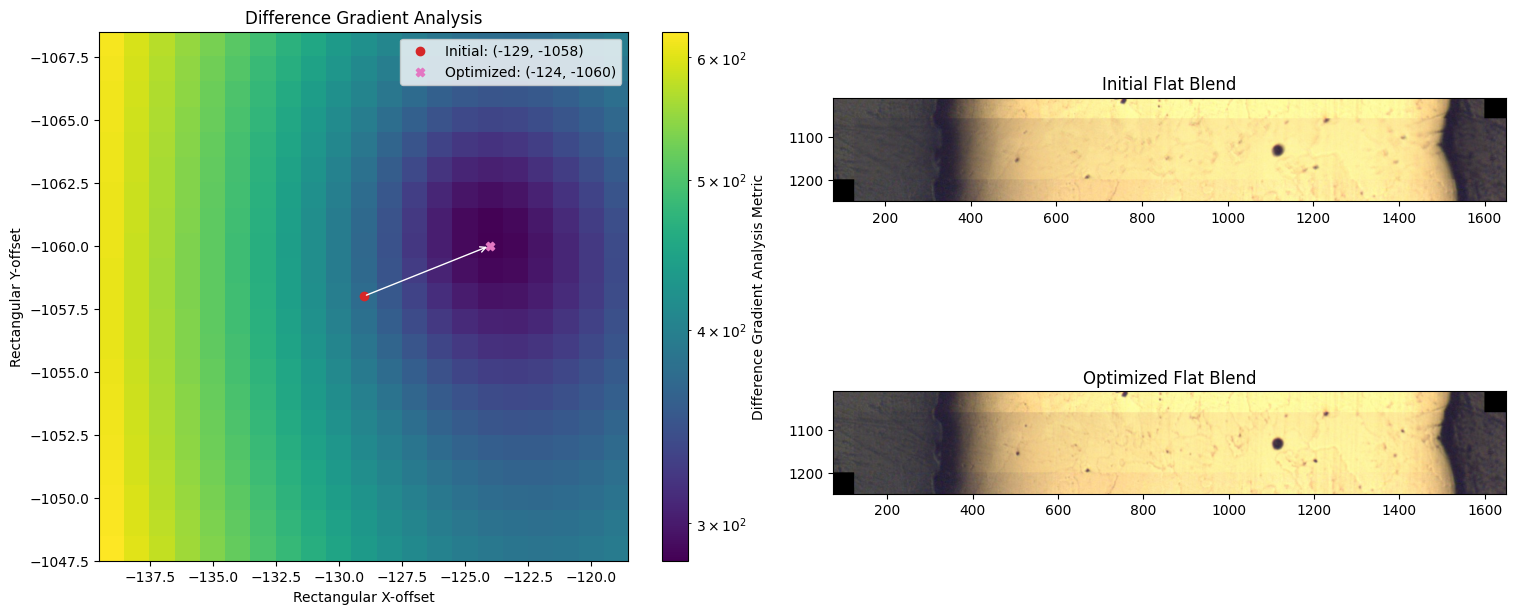

In [99]:
# Using `mis_project.get_relations()[1]` which has an ideal offset of `(8, -1146)`
# We can check strategy_max_size=50 which gives 101x101=10201 offsets.
# Not including plotting the cell takes 7.3s to run
def render_pair(
        image_a,
        image_b,
        relation:dict,
        weight=cr.weight_flat,
        return_canvas_relative_offsets=False
        ):
    origin_relative_offsets=cr.rectangular_solve(
        relations=[relation],
        image_names=[image_a.name,image_b.name],
        origin=image_a.name
        )

    origin_relative_extents=cr.find_relative_extents(
        image_names=[image_a.name,image_b.name],
        origin_relative_offsets=origin_relative_offsets,
        image_shapes={image_a.name:image_a.shape,image_b.name:image_b.shape}
        )

    canvas_extents, canvas_offsets=cr.resolve_extents(origin_relative_extents)

    canvas_relative_offsets=cr.place_in_canvas(
        image_names=[image_a.name,image_b.name],
        origin_relative_offsets=origin_relative_offsets,
        canvas_extents=canvas_extents,
        canvas_offsets=canvas_offsets)

    blender=cr.build_normalization(
        image_arrays={image_a.name:image_a,image_b.name:image_b},
        canvas_relative_offsets=canvas_relative_offsets,
        canvas_extents=canvas_extents,
        weight=cr.weight_flat,
        )
    render=cr.render_blended(
        image_arrays={image_a.name:image_a,image_b.name:image_b},
        canvas_relative_offsets=canvas_relative_offsets,
        canvas_extents=canvas_extents,
        weight=cr.weight_flat,
        normalizer=blender,
        )

    if return_canvas_relative_offsets:
        return render, canvas_relative_offsets
    else:
        return render
def plot_pair(
        image_a,
        image_b,
        relation:dict,
        weight=cr.weight_flat,
        focus_overlap=True,
        focus_expand=50
        ):
    render, canvas_relative_offsets=render_pair(
        image_a=image_a,
        image_b=image_b,
        relation=relation,
        weight=weight,
        return_canvas_relative_offsets=True)
    plt.imshow(render)
    if focus_overlap:
        a_spans,b_spans=dga.overlap_spans(
            offset_vector=relation["rel"],
            a_shape=image_a.shape,
            b_shape=image_b.shape)
        plt.xlim(left=canvas_relative_offsets[image_a.name][0]+a_spans[0][0]-focus_expand,right=canvas_relative_offsets[image_a.name][0]+a_spans[0][1]+focus_expand)
        plt.ylim(top=canvas_relative_offsets[image_a.name][1]+a_spans[1][0]-focus_expand,bottom=canvas_relative_offsets[image_a.name][1]+a_spans[1][1]+focus_expand)

def plot_grid_result(
        dga_grid_results:dict,
        overlays=True):
    plt.imshow(dga_grid_results["grid_results"].T,
        norm=colors.LogNorm(vmin=np.nanmin(dga_grid_results["grid_results"]),
                            vmax=np.nanmax(dga_grid_results["grid_results"])),
        extent=(np.min(dga_grid_results["grid"][0])-0.5,
                np.max(dga_grid_results["grid"][0])+0.5,
                np.max(dga_grid_results["grid"][1])+0.5,
                np.min(dga_grid_results["grid"][1])-0.5,), #xmin,xmax,ymin,ymax
        )
    plt.xlabel("Rectangular X-offset")
    plt.ylabel("Rectangular Y-offset")
    plt.colorbar(label="Difference Gradient Analysis Metric")

    if overlays:
        legend=False
        if "initial_offset" in dga_grid_results:
            plt.scatter(
                x=dga_grid_results["initial_offset"][0],
                y=dga_grid_results["initial_offset"][1],
                marker="o",
                color="tab:red",
                label=f'Initial: {dga_grid_results["initial_offset"]}')
            legend=True
        if "optimized_offset" in dga_grid_results:
            plt.scatter(
                x=dga_grid_results["optimized_offset"][0],
                y=dga_grid_results["optimized_offset"][1],
                marker="X",
                color="tab:pink",
                label=f'Optimized: {dga_grid_results["optimized_offset"]}')
            legend=True
        if "initial_offset" in dga_grid_results and "optimized_offset" in dga_grid_results:
            plt.annotate("", 
                xytext=dga_grid_results["initial_offset"],
                xy=dga_grid_results["optimized_offset"],
                arrowprops=dict(arrowstyle="->",color="w"),)
        if legend:
            plt.legend()

selected_relation=mis_project.get_relations()[2] #8 is particularly far away/good to visualize # 7 is neat for seeing how physical features effect plot.
dga_results=dga.difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        relation=selected_relation,
        strategy=dga.strategy_scaled_grid,
        metric=dga.metric_squared_mean,
        strategy_max_size=10,
        strategy_grid_scale=1,
        )
dga_results["initial_offset"]=selected_relation.get_relation("r")
print("Initial:",dga_results["initial_offset"],"Optimized:",dga_results["optimized_offset"])


fig,axs=plt.subplot_mosaic(
    mosaic=[
        ["Difference Gradient Analysis","Initial Flat Blend"],
        ["Difference Gradient Analysis","Optimized Flat Blend"]])
fig.set_figwidth(15)
fig.set_figheight(6)
plt.tight_layout(pad=1.5,h_pad=2,w_pad=2)

plt.sca(axs["Difference Gradient Analysis"])
plt.title("Difference Gradient Analysis")
plot_grid_result(
    dga_grid_results=dga_results,
    overlays=True)

plt.sca(axs["Initial Flat Blend"])
plt.title("Initial Flat Blend")
plot_pair(
    image_a=mis_project.get_image(selected_relation.get_reference()[0]),
    image_b=mis_project.get_image(selected_relation.get_reference()[1]),
    relation={'ref':selected_relation.get_reference(),'rel':selected_relation.get_relation('r')},
    weight=cr.weight_dfe)

plt.sca(axs["Optimized Flat Blend"])
plt.title("Optimized Flat Blend")
plot_pair(
    image_a=mis_project.get_image(selected_relation.get_reference()[0]),
    image_b=mis_project.get_image(selected_relation.get_reference()[1]),
    relation={'ref':selected_relation.get_reference(),'rel':dga_results["optimized_offset"]},
    weight=cr.weight_dfe)
plt.show()

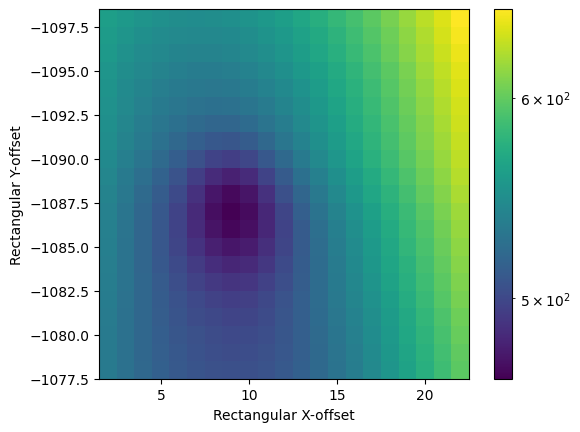

0 ('image_a01.jpg', 'image_a02.jpg') (12, -1088) -> (9, -1087)


<Figure size 640x480 with 0 Axes>

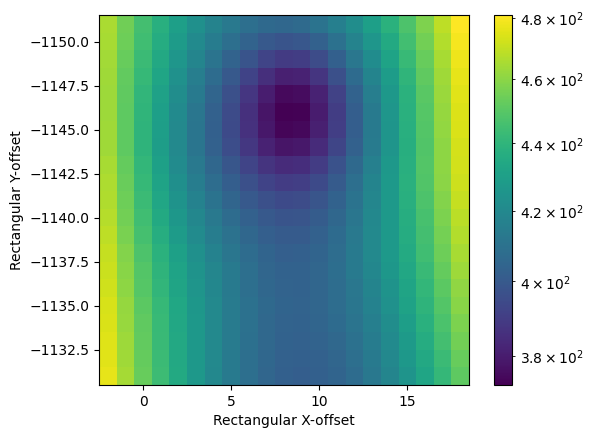

1 ('image_a02.jpg', 'image_a03.jpg') (8, -1141) -> (8, -1146)


<Figure size 640x480 with 0 Axes>

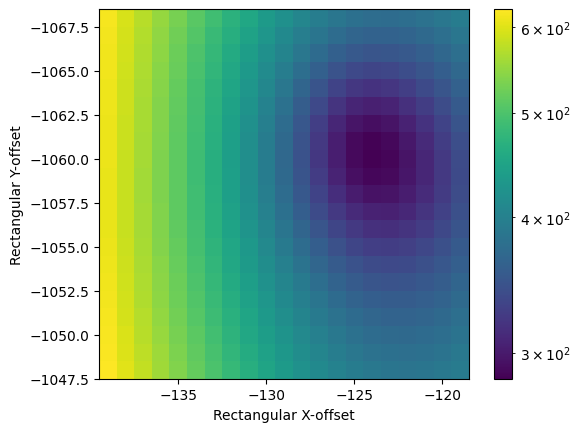

2 ('image_a03.jpg', 'image_a04.jpg') (-129, -1058) -> (-124, -1060)


<Figure size 640x480 with 0 Axes>

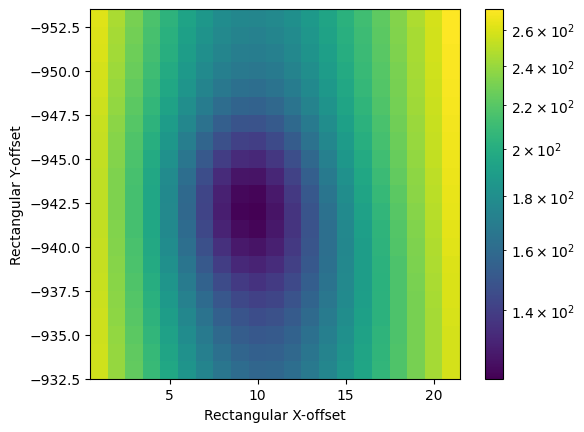

3 ('image_a04.jpg', 'image_a05.jpg') (11, -943) -> (10, -942)


<Figure size 640x480 with 0 Axes>

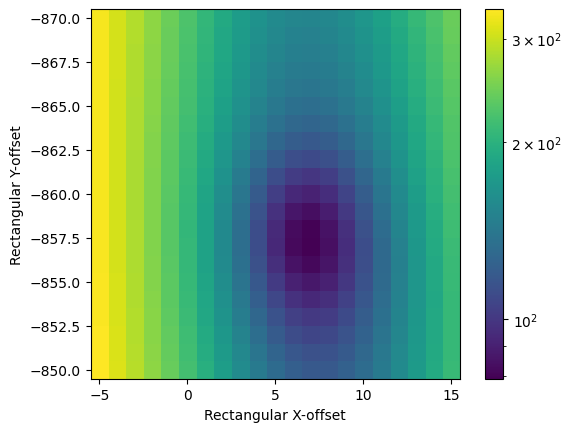

4 ('image_a05.jpg', 'image_a06.jpg') (5, -860) -> (7, -857)


<Figure size 640x480 with 0 Axes>

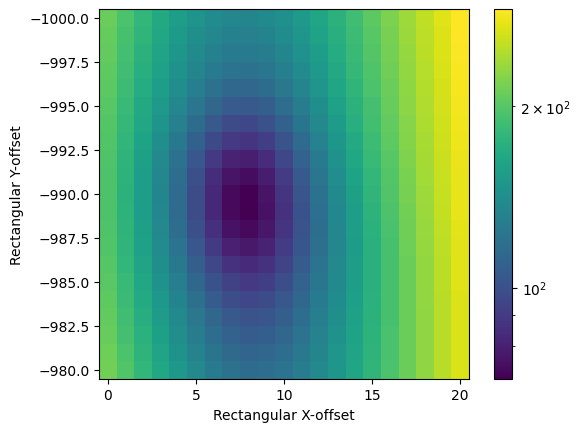

5 ('image_a06.jpg', 'image_a07.jpg') (10, -990) -> (8, -989)


<Figure size 640x480 with 0 Axes>

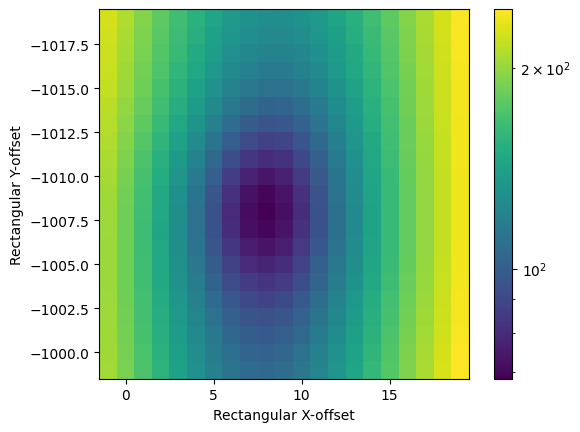

6 ('image_a07.jpg', 'image_a08.jpg') (9, -1009) -> (8, -1008)


<Figure size 640x480 with 0 Axes>

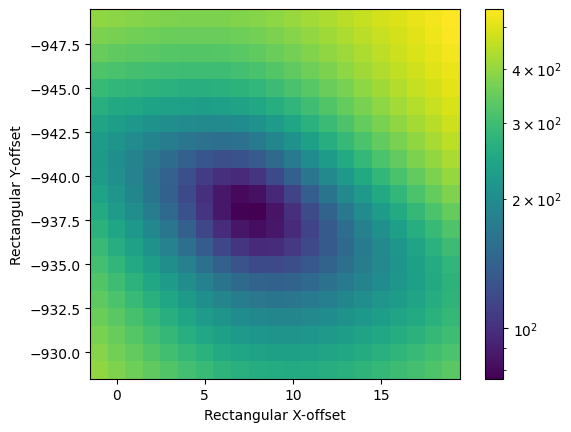

7 ('image_a08.jpg', 'image_a09.jpg') (9, -939) -> (8, -938)


<Figure size 640x480 with 0 Axes>

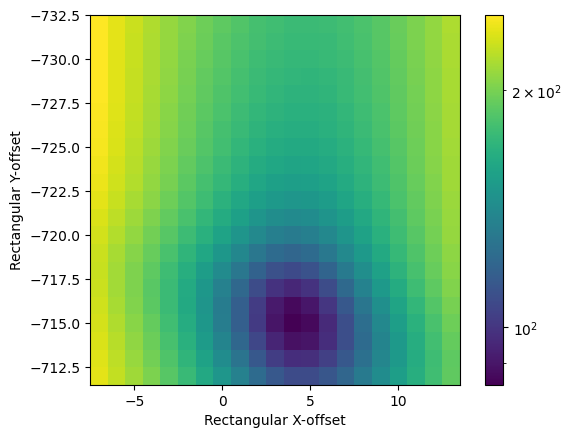

8 ('image_a09.jpg', 'image_a10.jpg') (3, -722) -> (4, -715)


<Figure size 640x480 with 0 Axes>

In [95]:
relation_index_results=dict()
for i,relation in enumerate(mis_project.get_relations()):
    dga_results=dga.difference_gradient_analysis(
            image_a=mis_project.get_image(relation.get_reference()[0]),
            image_b=mis_project.get_image(relation.get_reference()[1]),
            relation=relation,
            strategy=dga.strategy_full_grid,
            metric=dga.metric_squared_mean,
            strategy_max_size=10,
            )
    plt.figure()
    plt.imshow(dga_results["grid_results"].T,
        norm=colors.LogNorm(vmin=np.nanmin(dga_results["grid_results"]),
                            vmax=np.nanmax(dga_results["grid_results"])),
        extent=(np.min(dga_results["grid"][0])-0.5,
                np.max(dga_results["grid"][0])+0.5,
                np.max(dga_results["grid"][1])+0.5,
                np.min(dga_results["grid"][1])-0.5,), #xmin,xmax,ymin,ymax
        )
    plt.xlabel("Rectangular X-offset")
    plt.ylabel("Rectangular Y-offset")
    plt.colorbar()
    plt.show()
    relation_index_results[i]=MISRelationRectangular(image_pair=relation.get_reference(),
                                                                                rectangular=dga_results["optimized_offset"],
                                                                                note="Alignment with DGA")

    plt.figure()
    
    print(i,relation.get_reference(),relation.get_relation('r'),"->",dga_results["optimized_offset"])

In [ ]:
[mis_project.set_relation(i,relation) for i,relation in relation_index_results.items()]
mis_filepath="../example/project_a/project_a-dga_relations-calibrated.mis.json"
mis_project.save(mis_filepath)